In [38]:
import numpy as np
import os 
from tqdm import tqdm
import pandas as pd
import cv2
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import CustomObjectScope
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
import tensorflow.keras.layers as L

In [39]:
smooth = 1e-15
def dice_coef(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [40]:
model=tf.keras.models.load_model('/kaggle/input/attentionresunet/keras/default/1/attention_res_unet_best.keras',
                                custom_objects={'dice_loss': dice_loss, 'dice_coef': dice_coef})

In [41]:
# Input directory (contains original images)
input_dir = "/kaggle/input/brain-tumor-segmentation/images"
all_images = sorted(glob(os.path.join(input_dir, "*.png")))

# Output directory for masks
output_dir = "/kaggle/working/all_masks"
os.makedirs(output_dir, exist_ok=True)

In [42]:
def segment_and_save(image_paths, model, output_dir, img_size=(256,256)):
    for img_path in tqdm(image_paths):
        # Load and preprocess image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, img_size)
        x = image/255.0
        x = np.expand_dims(x, axis=0)  # Add batch dimension
        
        # Predict mask
        pred_mask = model.predict(x, verbose=0)[0]
        pred_mask = np.squeeze(pred_mask)  # Remove channel dim
        binary_mask = (pred_mask > 0.5).astype(np.uint8) * 255  # Threshold and scale
        
        # Save mask
        mask_name = os.path.basename(img_path)
        output_path = os.path.join(output_dir, mask_name)
        cv2.imwrite(output_path, binary_mask)

In [43]:
# Process all images
segment_and_save(all_images, model, output_dir)
print(f"Saved {len(all_images)} masks to {output_dir}")

100%|██████████| 3064/3064 [04:59<00:00, 10.25it/s]

Saved 3064 masks to /kaggle/working/all_masks


In [44]:
import numpy as np
import cv2
import os
from tensorflow.keras.utils import to_categorical


def load_and_preprocess(image_dir, mask_dir, label_df, target_size=(256, 256), num_classes=3):
    X = []
    y = []

    for idx, row in label_df.iterrows():
        filename = row['filename']
        label = row['label']

        # Build full paths
        img_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)

        # Read and resize
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, target_size)
        img = img / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, target_size)
        mask = mask / 255.0

        # Stack grayscale image and mask as 2 channels
        input_tensor = np.stack([img, mask], axis=-1)
        X.append(input_tensor)
        y.append(label)

    X = np.array(X)
    y = to_categorical(np.array(y), num_classes=num_classes)  # One-hot encode labels

    return X, y

In [45]:
image_dir='/kaggle/input/brain-tumor-segmentation/images'
mask_dir='/kaggle/working/all_masks'

In [46]:
labels_df=pd.read_csv('/kaggle/input/figshare-label/labels (1).csv')

In [47]:
labels_df

,filename,label
0,2912.png,1
1,2011.png,1
2,3027.png,1
3,1912.png,1
4,3023.png,1
...,...,...
3059,1248.png,2
3060,2374.png,1
3061,1437.png,2
3062,1119.png,2


In [48]:
labels_df['label'] = labels_df['label'].astype(int)
labels = labels_df['label'].values

In [49]:
np.unique(labels)

array([0, 1, 2])

In [50]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# y should be your integer labels (not one-hot)
classes = np.unique(labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)

# Convert to dictionary format for Keras
class_weights_dict = dict(zip(classes, class_weights))

print("Computed class weights:", class_weights_dict)

Computed class weights: {0: 1.4425612052730696, 1: 0.7162225338943432, 2: 1.0982078853046595}


In [51]:
X, y = load_and_preprocess(image_dir, mask_dir, labels_df)

In [52]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2451, 256, 256, 2)
(613, 256, 256, 2)
(2451, 3)
(613, 3)


In [54]:
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.optimizers import Adam

lr_schedule = CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=19200,
    alpha=0.001
)

optimizer = Adam(learning_rate=lr_schedule)


In [55]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionV3

# Define the 2-channel input
input_tensor = Input(shape=(256, 256, 2))

# Convert 2-channel input to 3-channel
x = Conv2D(3, (3, 3), padding='same', activation='relu')(input_tensor)

# Load base model on top of converted input
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_output = base_model(x)
base_model.trainable = False

# Classification head
x = GlobalAveragePooling2D()(base_output)
x = Dropout(0.5)(x)
x = Dense(256,kernel_regularizer=tf.keras.regularizers.l2(1e-3), activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

# Define model
model = Model(inputs=input_tensor, outputs=output)

# Compile
model.compile(optimizer=optimizer,
              loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 256, 256, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_95 (Conv2D)                   │ (None, 256, 256, 3)         │              57 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ inception_v3 (Functional)            │ (None, 6, 6, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,328,156 (85.18 MB)

 Trainable params: 525,372 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [56]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=150,
    batch_size=16,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("inception_mask_model.keras", save_best_only=True),
        #tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=5)
    ],
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 43s 186ms/step - accuracy: 0.6155 - loss: 1.3907 - val_accuracy: 0.8333 - val_loss: 0.9193
Epoch 2/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.7740 - loss: 0.9508 - val_accuracy: 0.8496 - val_loss: 0.7762
Epoch 3/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8233 - loss: 0.8413 - val_accuracy: 0.8496 - val_loss: 0.7670
Epoch 4/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.8360 - loss: 0.7805 - val_accuracy: 0.8008 - val_loss: 0.8314
Epoch 5/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8124 - loss: 0.7556 - val_accuracy: 0.8618 - val_loss: 0.6733
Epoch 6/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8282 - loss: 0.7245 - val_accuracy: 0.8618 - val_loss: 0.6651
Epoch 7/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.8644 - loss: 0.6665 - val_accuracy: 0.8415 - val_loss: 0.6823
Epoch 8/150
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8344 - loss: 0.6

In [57]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.9436 - loss: 0.3622

Test Accuracy: 93.80%


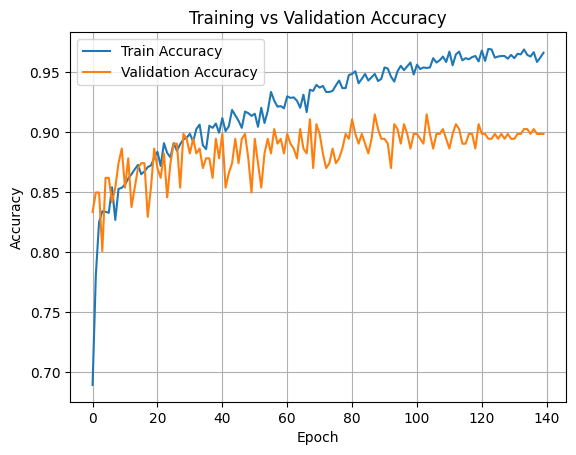

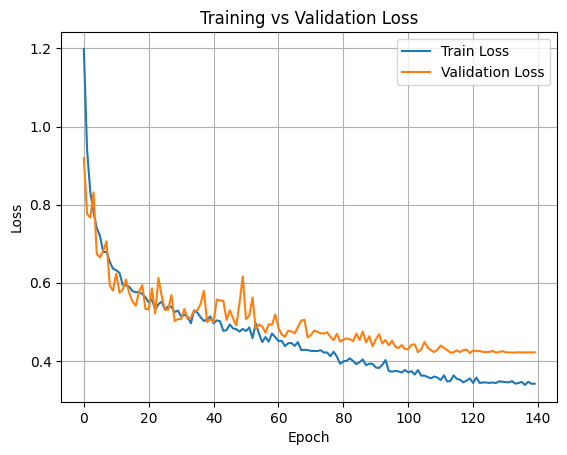

In [58]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
class_names = ["Meningioma", "Glioma", "Pituitary"]

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 396ms/step
Classification Report:

              precision    recall  f1-score   support

  Meningioma       0.89      0.89      0.89       142
      Glioma       0.95      0.93      0.94       285
   Pituitary       0.95      0.98      0.96       186

    accuracy                           0.94       613
   macro avg       0.93      0.94      0.93       613
weighted avg       0.94      0.94      0.94       613



<Figure size 800x600 with 0 Axes>

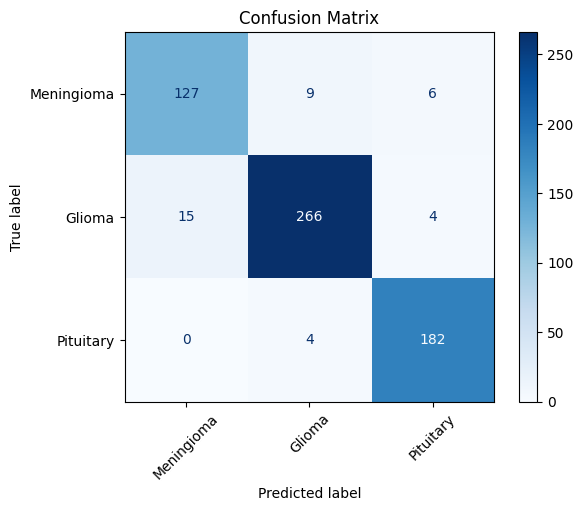

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Get predicted class labels
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Classification report (includes classwise accuracy = precision/recall/f1)
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# 4. Plot confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

In [61]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_accuracy):
    print(f"Accuracy for {class_names[i]}: {acc:.2%}")

Accuracy for Meningioma: 89.44%
Accuracy for Glioma: 93.33%
Accuracy for Pituitary: 97.85%
